# exp05_metrics.ipynb
**Цель:** На основе metrics.csv выбрать лучший подход, сохранить сравнительный график

Сводка всех экспериментов:


,experiment,model,accuracy,f1_macro
2,cnn_variants,CNN_Baseline,0.582973,0.467828
3,cnn_variants,CNN_Improved,0.549673,0.428742
7,cnn_variants,CNN_aug_combined,0.440295,0.293567
4,cnn_variants,CNN_aug_base,0.367284,0.288656
6,cnn_variants,CNN_aug_photo,0.375923,0.264371
5,cnn_variants,CNN_aug_geo,0.337606,0.257272
0,baselines,LogisticRegression,0.263759,0.254649
1,baselines,RandomForest,0.244392,0.201643



Лучший подход: CNN_Baseline (F1=0.468)


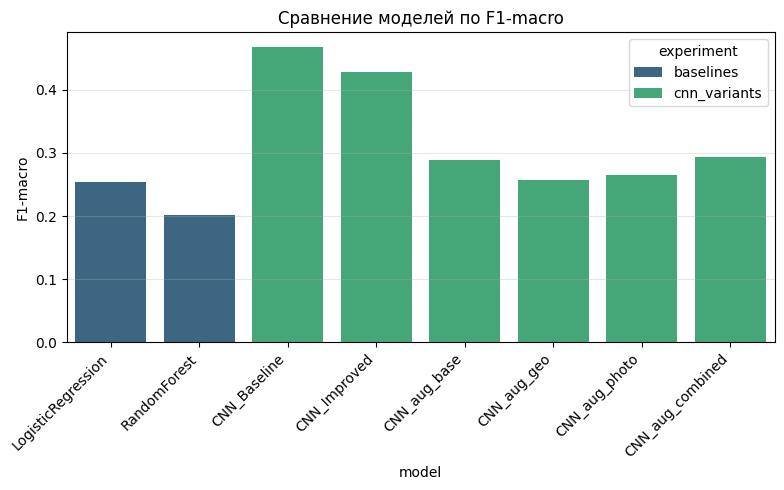

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from src.constants import ARTIFACTS_PATH, FIGURES_PATH

ROOT = Path.cwd().parent
df = pd.read_csv(f"{ARTIFACTS_PATH}/metrics.csv")
print("Сводка всех экспериментов:")
display(df[["experiment", "model", "accuracy", "f1_macro"]].sort_values("f1_macro", ascending=False))

best = df.loc[df["f1_macro"].idxmax()]
print(f"\nЛучший подход: {best['model']} (F1={best['f1_macro']:.3f})")

plt.figure(figsize=(8,5))
sns.barplot(data=df, x="model", y="f1_macro", hue="experiment", palette="viridis", dodge=False)
plt.xticks(rotation=45, ha="right")
plt.title("Сравнение моделей по F1-macro")
plt.ylabel("F1-macro")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/final_comparison.png", dpi=150)
plt.show()